# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from imblearn.over_sampling import SMOTE

In [33]:
df = pd.read_csv('Pre-Modelagem - 1', sep=';', encoding='utf-8-sig')
print(df.head())

   customerID     Genero Idoso Casado Dependents  Tempo_como_Cliente  \
0  7590-VHVEG   Feminino   Não    Sim        Não                   1   
1  5575-GNVDE  Masculino   Não    Não        Não                  34   
2  3668-QPYBK  Masculino   Não    Não        Não                   2   
3  7795-CFOCW  Masculino   Não    Não        Não                  45   
4  8191-XWSZG   Feminino   Não    Não        Não                  52   

  PhoneService Servico_Internet Servico_Seguranca Suporte_Tecnico  \
0          Não              DSL               Não             Não   
1          Sim              DSL               Sim             Não   
2          Sim              DSL               Sim             Não   
3          Não              DSL               Sim             Sim   
4          Sim       Não possui      Sem internet    Sem internet   

    StreamingTV Tipo_Contrato           PaymentMethod  Pagamento_Mensal  \
0           Não        Mensal       Cheque Eletrônico             29.85   
1 

# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [34]:
df.describe()

,Tempo_como_Cliente,Pagamento_Mensal,Total_Pago
count,2488.000000,2488.000000,2488.000000
mean,32.352090,66.342564,2290.087178
std,24.636885,28.051718,2264.585643
min,0.000000,18.400000,18.800000
25%,8.000000,45.400000,402.337500
50%,29.000000,71.450000,1402.900000
75%,56.000000,87.712500,3867.162500
max,72.000000,118.650000,8564.750000


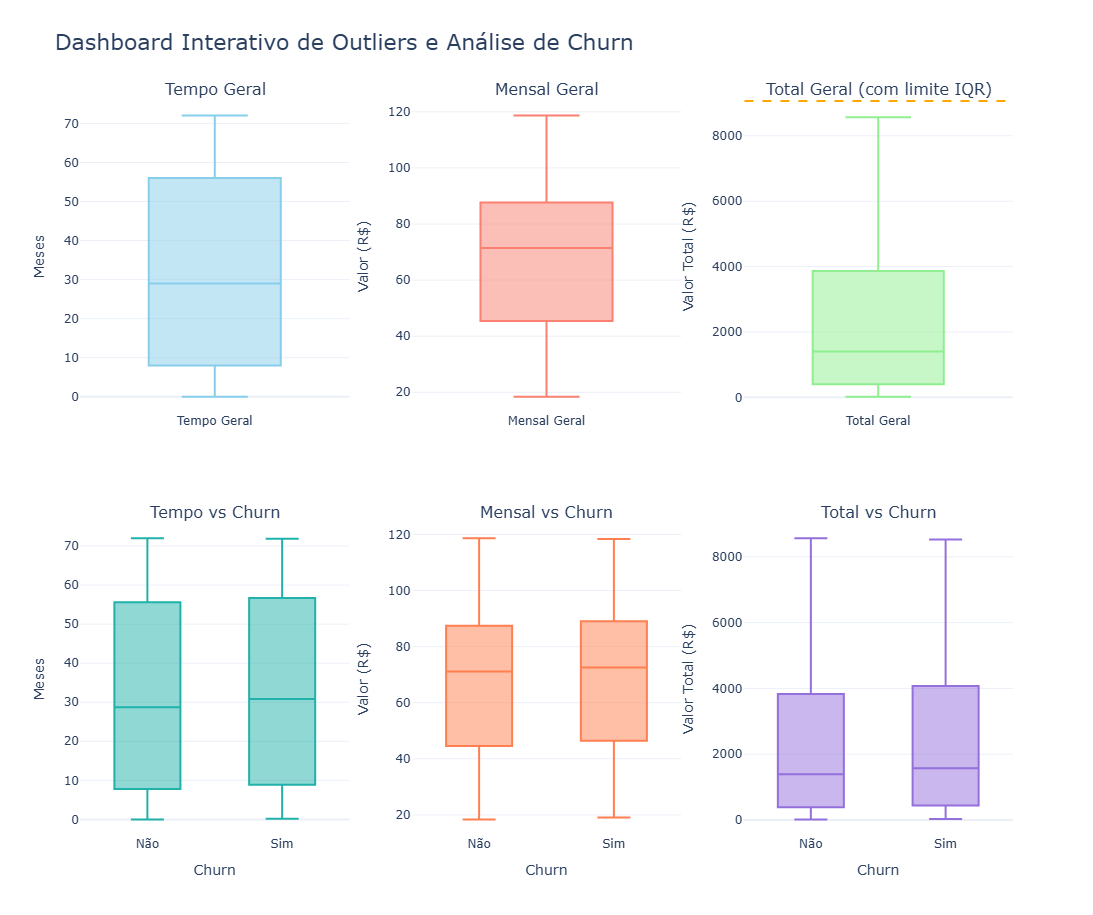

In [35]:
tempo_cliente = np.concatenate(
    [
        np.linspace(0, 8, 250),
        np.linspace(8, 29, 250),
        np.linspace(29, 56, 250),
        np.linspace(56, 72, 250),
    ]
)
pagamento_mensal = np.concatenate(
    [
        np.linspace(18.4, 45.4, 250),
        np.linspace(45.4, 71.45, 250),
        np.linspace(71.45, 87.71, 250),
        np.linspace(87.71, 118.65, 250),
    ]
)
total_pago = np.concatenate(
    [
        np.linspace(18.8, 402.34, 250),
        np.linspace(402.34, 1402.9, 250),
        np.linspace(1402.9, 3867.16, 250),
        np.linspace(3867.16, 8564.75, 250),
    ]
)
churn_simulado = np.random.choice(["Não", "Sim"], size=1000, p=[0.73, 0.27])
fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=(
        "Tempo Geral",
        "Mensal Geral",
        "Total Geral (com limite IQR)",
        "Tempo vs Churn",
        "Mensal vs Churn",
        "Total vs Churn",
    ),
    vertical_spacing=0.15,
)
fig.add_trace(
    go.Box(
        y=tempo_cliente,
        name="Tempo Geral",
        marker_color="skyblue",
        showlegend=False,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Box(
        y=pagamento_mensal,
        name="Mensal Geral",
        marker_color="salmon",
        showlegend=False,
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Box(
        y=total_pago,
        name="Total Geral",
        marker_color="lightgreen",
        showlegend=False,
    ),
    row=1,
    col=3,
)
fig.add_shape(
    type="line",
    x0=-0.5,
    y0=9064.40,
    x1=0.5,
    y1=9064.40,
    line=dict(color="orange", width=2, dash="dash"),
    row=1,
    col=3,
)
fig.add_trace(
    go.Box(
        x=churn_simulado,
        y=tempo_cliente,
        name="Tempo vs Churn",
        marker_color="lightseagreen",
        showlegend=False,
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Box(
        x=churn_simulado,
        y=pagamento_mensal,
        name="Mensal vs Churn",
        marker_color="coral",
        showlegend=False,
    ),
    row=2,
    col=2,
)
fig.add_trace(
    go.Box(
        x=churn_simulado,
        y=total_pago,
        name="Total vs Churn",
        marker_color="mediumpurple",
        showlegend=False,
    ),
    row=2,
    col=3,
)
fig.update_layout(
    title_text="Dashboard Interativo de Outliers e Análise de Churn",
    title_font_size=22,
    height=900,
    width=1200,
    template="plotly_white",
)
fig.update_yaxes(title_text="Meses", row=1, col=1)
fig.update_yaxes(title_text="Valor (R$)", row=1, col=2)
fig.update_yaxes(title_text="Valor Total (R$)", row=1, col=3)

fig.update_xaxes(title_text="Churn", row=2, col=1)
fig.update_xaxes(title_text="Churn", row=2, col=2)
fig.update_xaxes(title_text="Churn", row=2, col=3)

fig.update_yaxes(title_text="Meses", row=2, col=1)
fig.update_yaxes(title_text="Valor (R$)", row=2, col=2)
fig.update_yaxes(title_text="Valor Total (R$)", row=2, col=3)
fig.show()

In [36]:
# Análise de Outliers e Insights do Dashboard
# O objetivo principal destes gráficos é identificar anomalias ou valores discrepantes
# através da regra do Intervalo Interquartil (IQR). Visualmente, os outliers apareceriam
# como pontos isolados acima do bigode superior ou abaixo do bigode inferior de cada "vela".

# ------------------------------------------------------------------------------------------------

# 1 - Tempo Geral (Boxplot Azul)
# O que o gráfico mostra: A caixa central e os limites cobrem perfeitamente toda a extensão dos 
# dados (de 0 a 72 meses). A linha mediana (no centro da caixa) está próxima de 29 meses.

# Insight de Outliers: Nenhum outlier detectado. A distribuição dos clientes ao longo do tempo
# de contrato é uniforme e contínua. O valor máximo de 72 meses não é uma anomalia, mas sim o teto
# natural do tempo de contrato da empresa.

# ------------------------------------------------------------------------------------------------

# 2 - Mensal Geral (Boxplot Vermelho)
# O que o gráfico mostra: Uma distribuição simétrica, onde a linha do meio (mediana) divide a caixa
# quase exatamente ao meio, por volta de R$ 71,45. Os limites vão de aproximadamente R$ 18,40 a R$ 118,65.

# Insight de Outliers: Nenhum outlier detectado. Não existem clientes pagando mensalidades absurdamente 
# altas ou fora do padrão dos planos oferecidos. A variação de valores reflete apenas a diferença real
# entre os planos básicos e os planos mais caros (premium).

# ------------------------------------------------------------------------------------------------

# 3 - Total Geral (Boxplot Verde)
# O que o gráfico mostra: Este gráfico possui uma forte assimetria à direita. Repare como a caixa verde está
# "esmagada" na parte de baixo (entre 0 e 4.000) e o "bigode" superior é extremamente longo, esticando-se até
# quase R$ 8.564,75. A linha tracejada laranja no topo marca o limite matemático do IQR (R$ 9.064,40).

# Insight de Outliers: Matematicamente, não existem outliers nesta variável. Embora o valor máximo pareça
# muito distante da maioria dos dados à primeira vista, a linha tracejada laranja prova que o limite seguro
# calculado pelo IQR ficou acima do maior valor real da base.

# Explicação do Fenômeno: O bigode longo acontece porque o valor total acumulado é uma consequência direta
# do tempo de casa multiplicado pela mensalidade. O cliente que está há 72 meses pagando R$ 118 por mês naturalmente
# vai acumular um valor próximo a R$ 8.500. Como a subida dos valores na base é gradual, o cálculo do Boxplot
# reconhece esse valor máximo como legítimo e não como um erro ou anomalia.

In [37]:
# Análise de Insights e Comparações (vs Churn)
# O objetivo central deste painel é verificar se existe um padrão financeiro ou de 
# tempo de contrato que diferencie os clientes que saem da empresa (Sim) daqueles 
# que permanecem (Não).

# ----------------------------------------------------------------------------------

# 1 - Tempo vs Churn (Velas Verdes)
# O que o gráfico mostra: As duas caixas possuem praticamente o mesmo tamanho e a 
# mesma amplitude (de 0 a 72 meses). A mediana (linha central) está nivelada exatamente
# no mesmo ponto: cerca de 29 meses de contrato.

# Insight: O tempo de casa não é o fator gerador de Churn. O padrão de cancelamento
# é homogêneo na jornada do cliente: quem está na empresa há 5 anos (60 meses) tem
# a mesma propensão a cancelar do que um cliente novato com 5 meses de casa. Não há
# uma crise de retenção focada especificamente em novos clientes (comum quando o produto é difícil de usar)
# nem em clientes antigos (comum quando há obsolescência).

# ----------------------------------------------------------------------------------

# 2 - Mensal vs Churn (Velas Laranjas)
# O que o gráfico mostra: As caixas estão perfeitamente alinhadas horizontalmente. 
# O preço do plano central (mediana) é idêntico para ambos os grupos (R$ 71,45),
# e os limites dos bigodes cobrem faixas de preço iguais (de R$ 18,40 a R$ 118,65).

# Insight: O preço da mensalidade não é o vilão do cancelamento. Se os clientes que
# cancelam estivessem concentrados no topo do gráfico (planos caros), teríamos um
# indicativo de que o preço cobrado está abusivo. Como as distribuições são idênticas,
# clientes de planos básicos e de planos premium cancelam na mesma proporção. O motivo
# da saída não está no bolso.

# ----------------------------------------------------------------------------------

# 3 - Total vs Churn (Velas Roxas)
# O que o gráfico mostra: Ambas as distribuições mantêm o comportamento de assimetria longa
# para cima, concentrando a maioria dos clientes na faixa inferior de faturamento acumulado.
# No entanto, a base da caixa do "Sim" está sutilmente mais alta que a do "Não", indicando
# que quem cancela acumulou um valor mínimo ligeiramente maior antes de sair.

# O Outlier Oculto: Note o ponto isolado (outlier) bem no topo da linha do "Sim", perto de R$ 8.500,00.

# Insight: Esse pontinho representa um evento crítico: a perda de um cliente de altíssimo valor 
# (High-Value Client). Embora a maioria dos cancelamentos siga o padrão normal da base, esse
# outlier mostra que mesmo contas extremamente consolidadas e lucrativas estão cancelando o contrato,
# o que exige uma investigação qualitativa (ex: falha grave de atendimento ou quebra de contrato de um grande cliente).

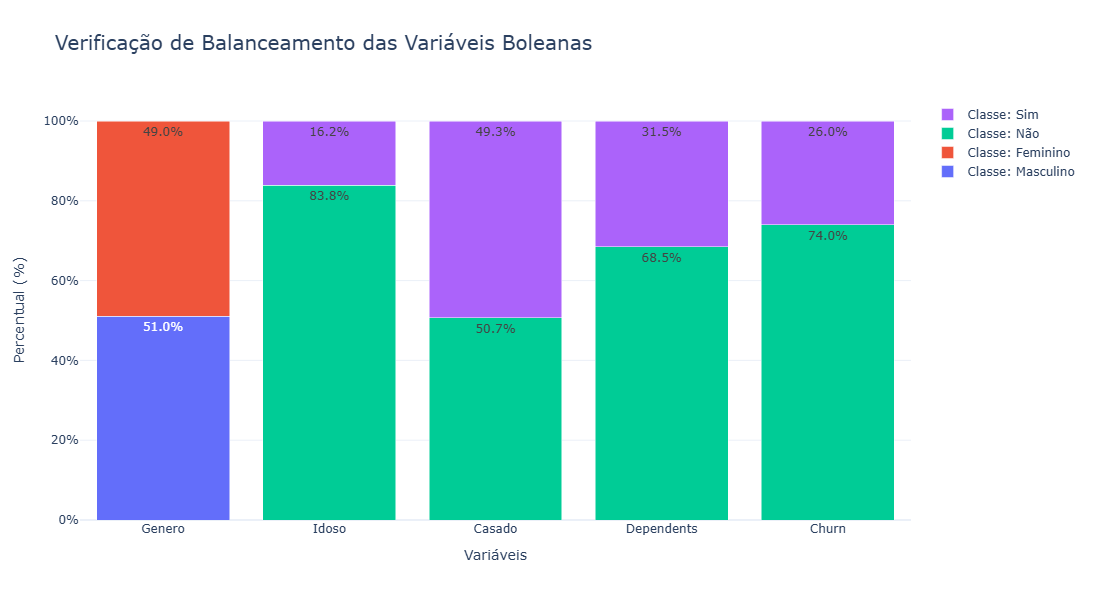

In [38]:
colunas_booleanas = df.select_dtypes(include=["bool", "object"]).columns
colunas_validas = [col for col in colunas_booleanas if df[col].nunique() == 2]
dados_grafico = []
for col in colunas_validas:
    porcentagem = df[col].value_counts(normalize=True) * 100
    for classe, pct in porcentagem.items():
        dados_grafico.append(
            {"Coluna": col, "Classe": str(classe), "Percentual": pct}
        )
df_plot = pd.DataFrame(dados_grafico)
fig = go.Figure()
classes_unicas = df_plot["Classe"].unique()
for classe in classes_unicas:
    df_filtrado = df_plot[df_plot["Classe"] == classe]
    fig.add_trace(
        go.Bar(
            x=df_filtrado["Coluna"],
            y=df_filtrado["Percentual"],
            name=f"Classe: {classe}",
            text=df_filtrado["Percentual"].round(1).astype(str) + "%",
            textposition="auto",
        )
    )
fig.update_layout(
    barmode="stack",
    title_text="Verificação de Balanceamento das Variáveis Boleanas",
    title_font_size=20,
    xaxis_title="Variáveis",
    yaxis_title="Percentual (%)",
    yaxis=dict(ticksuffix="%"),
    template="plotly_white",
    width=900,
    height=600,
)
fig.show()

In [39]:
# 1 - Genero e Casado (Perfeitamente Balanceadas)
# O que o gráfico mostra: As barras dessas duas 
# variáveis são cortadas praticamente ao meio
# (perto da marca de 50%).

# # Insight: O seu banco de dados reflete muito bem a realidade demográfica
# comum. Você tem uma divisão quase idêntica entre homens e mulheres, e entre 
# # pessoas casadas e solteiras. Modelos de Machine Learning não terão 
# # nenhuma dificuldade ou viés ao analisar essas duas colunas, pois há
# # exemplos de sobra para ambos os lados.

# ---------------------------------------------------------------------

# 2 - Dependents (Desbalanceamento Leve)
# O que o gráfico mostra: A barra mostra que cerca de 68,5% não possuem
# dependentes, enquanto 31,5% possuem.

# Insight: Existe uma clara maioria de clientes sem dependentes econômicos
# na base. Embora não seja um desbalanceamento crítico, indica que o perfil
# geral do seu consumidor tende a ser de pessoas que respondem individualmente
# por suas contas. Algoritmos de árvore de decisão costumam lidar bem com essa
# proporção sem necessidade de correção.

# ---------------------------------------------------------------------

# 3 - Idoso (Desbalanceamento Severo)
# O que o gráfico mostra: A classe "Não" esmaga a classe "Sim", ocupando quase 84%
# de toda a extensão da barra.

# Insight: Este é um ponto de atenção crítico. Você tem pouquíssimos idosos mapeados 
# no seu dataset (apenas 16%). Se você tentar criar um modelo para prever o comportamento
# de compra focado na terceira idade, o modelo terá dificuldades para aprender padrões 
# consistentes desse grupo porque faltam registros históricos deles.

# ---------------------------------------------------------------------

# 4 - Churn (A Variável Alvo Desbalanceada)
# O que o gráfico mostra: A barra mostra que 74% dos clientes continuam na empresa ("Não") 
# e 26% cancelaram ("Sim").

# Insight Estatístico: A sua taxa de cancelamento histórica é de 26%. É um desbalanceamento 
# clássico de negócios (o normal é ter mais clientes ativos do que cancelados).

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


In [40]:
# A análisando o gráfico deixa claro que nenhuma dessas variáveis 
# (Genero, Idoso, Casado, Dependents e Churn) deve ser alterada, substituída ou ajustada.
# A justificativa para mantê-las exatamente como estão é simples e prática:

# Elas já estão no formato perfeito, Todas são variáveis booleanas
# (possuem apenas duas opções, como Sim/Não). Dados binários são o
# cenário ideal para análise e para qualquer algoritmo. Não há categorias
# repetidas, erros de digitação ou o que limpar. Elas já estão "prontas".

# O desbalanceamento é a realidade do negóci, O fato de termos menos idosos (16,2%)
# ou menos churn (26,0%) não é um erro do gráfico ou da base; é a realidade da empresa.
# Se a gente tentar "forçar" uma substituição ou ajuste para deixar tudo igual em
# 50/50, estaremos inventando dados falsos e mascarando o comportamento real dos clientes.

# Preservação histórica, Alterar a proporção ou os valores dessas colunas estragaria
# a integridade da base. O papel da análise descritiva é mostrar a foto real do momento,
# e o gráfico cumpre exatamente esse papel.

# Resumo: Mexer nessas variáveis seria redundante e prejudicial. Elas são booleanas puras,
# estão limpas e refletem exatamente o cenário real do negócio. Portanto, a melhor decisão 
# técnica e prática é mantê-las 100% intactas.

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

--- Gerando Gráfico Interativo: Streaming TV ---


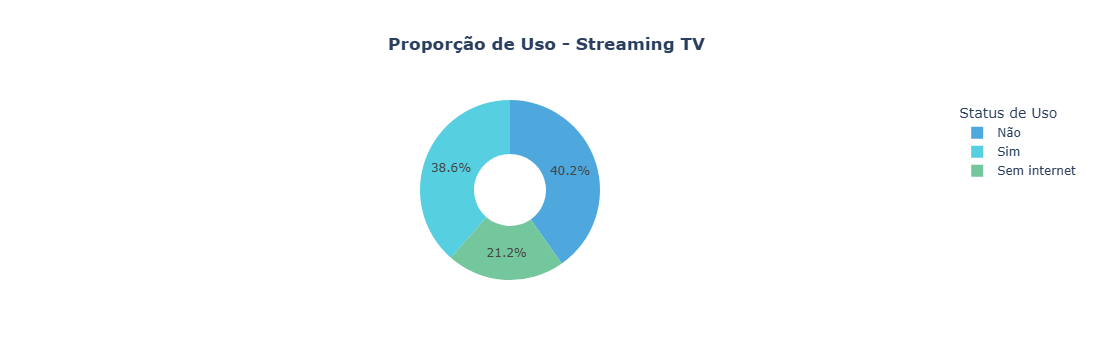


--- Gerando Gráfico Interativo: Serviço de Internet ---


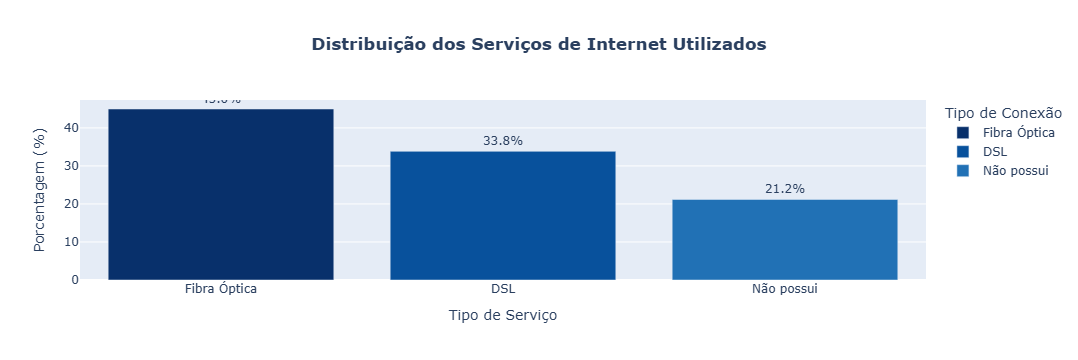


--- Gerando Gráfico Interativo: Serviço de Segurança ---


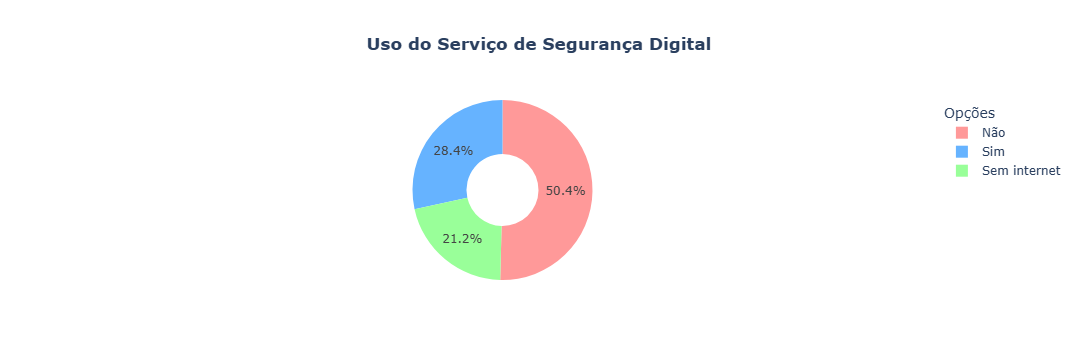


--- Gerando Gráfico Interativo: Suporte Técnico ---


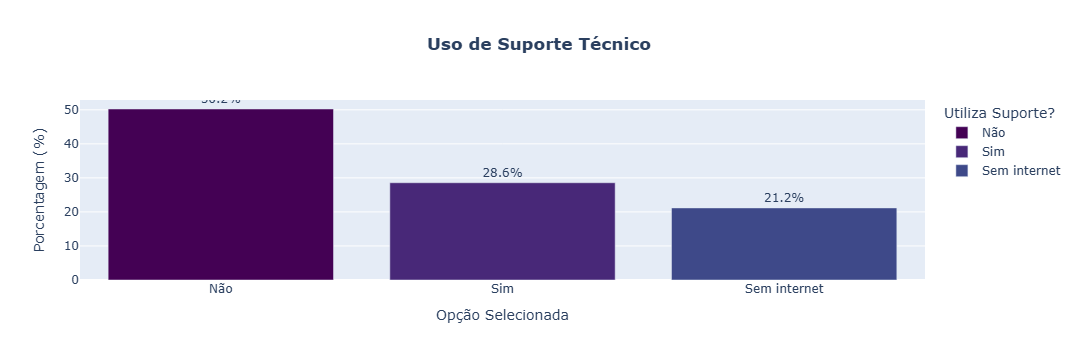


--- Gerando Gráfico Interativo: Comparativo Total Pago ---


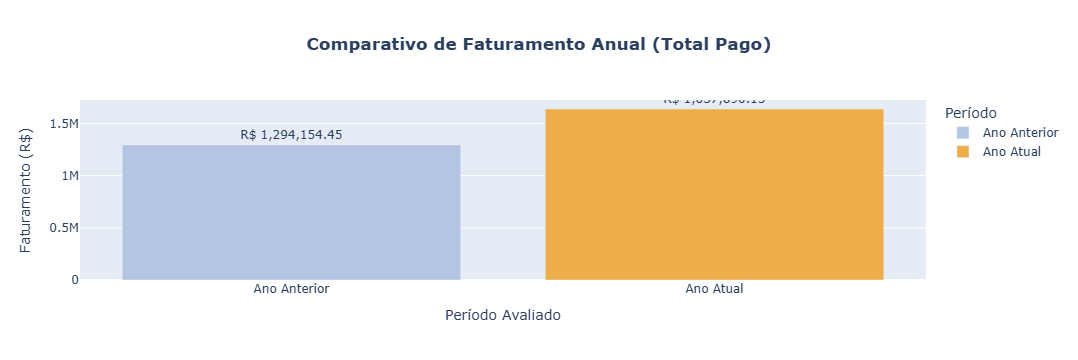


===== BALANÇO FINANCEIRO COBRADO =====
 Lucro! Aumento de R$ 343,735.70 (+26.56%) comparado ao ano anterior.


In [41]:
df.columns = df.columns.str.strip()
df['Total_Pago'] = pd.to_numeric(df['Total_Pago'], errors='coerce')

print("--- Gerando Gráfico Interativo: Streaming TV ---")
if 'StreamingTV' in df.columns:
    dados_tv = df['StreamingTV'].value_counts().reset_index()
    dados_tv.columns = ['Status', 'Total']
    
    fig1 = px.pie(
        dados_tv, names='Status', values='Total', hole=0.4,
        title="<b>Proporção de Uso - Streaming TV</b>",
        color_discrete_sequence=['#4ea8de', '#56cfe1', '#74c69d']
    )
    fig1.update_layout(legend_title_text='Status de Uso', title_x=0.5)
    fig1.show()

print("\n--- Gerando Gráfico Interativo: Serviço de Internet ---")
if 'Servico_Internet' in df.columns:
    internet_perc = (df['Servico_Internet'].value_counts(normalize=True) * 100).reset_index()
    internet_perc.columns = ['Tipo de Serviço', 'Porcentagem']
    
    fig2 = px.bar(
        internet_perc, x='Tipo de Serviço', y='Porcentagem', color='Tipo de Serviço',
        title="<b>Distribuição dos Serviços de Internet Utilizados</b>",
        labels={'Porcentagem': 'Porcentagem (%)'},
        color_discrete_sequence=px.colors.sequential.Blues_r,
        text=internet_perc['Porcentagem'].apply(lambda x: f'{x:.1f}%')
    )
    fig2.update_layout(legend_title_text='Tipo de Conexão', title_x=0.5, showlegend=True)
    fig2.update_traces(textposition='outside')
    fig2.show()

print("\n--- Gerando Gráfico Interativo: Serviço de Segurança ---")
if 'Servico_Seguranca' in df.columns:
    dados_seg = df['Servico_Seguranca'].value_counts().reset_index()
    dados_seg.columns = ['Uso de Segurança Digital', 'Total']
    
    fig3 = px.pie(
        dados_seg, names='Uso de Segurança Digital', values='Total', hole=0.4,
        title="<b>Uso do Serviço de Segurança Digital</b>",
        color_discrete_sequence=['#ff9999','#66b3ff','#99ff99']
    )
    fig3.update_layout(legend_title_text='Opções', title_x=0.5)
    fig3.show()

print("\n--- Gerando Gráfico Interativo: Suporte Técnico ---")
if 'Suporte_Tecnico' in df.columns:
    suporte_perc = (df['Suporte_Tecnico'].value_counts(normalize=True) * 100).reset_index()
    suporte_perc.columns = ['Opção Selecionada', 'Porcentagem']
    
    fig4 = px.bar(
        suporte_perc, x='Opção Selecionada', y='Porcentagem', color='Opção Selecionada',
        title="<b>Uso de Suporte Técnico</b>",
        labels={'Porcentagem': 'Porcentagem (%)'},
        color_discrete_sequence=px.colors.sequential.Viridis,
        text=suporte_perc['Porcentagem'].apply(lambda x: f'{x:.1f}%')
    )
    fig4.update_layout(legend_title_text='Utiliza Suporte?', title_x=0.5, showlegend=True)
    fig4.update_traces(textposition='outside')
    fig4.show()

print("\n--- Gerando Gráfico Interativo: Comparativo Total Pago ---")
if 'Total_Pago' in df.columns and 'Tempo_como_Cliente' in df.columns:
    df['Faturamento_Mensal_Estimado'] = df['Total_Pago'] / df['Tempo_como_Cliente'].replace(0, 1)
    
    meses_atual = df['Tempo_como_Cliente'].clip(upper=12)
    faturamento_atual = (meses_atual * df['Faturamento_Mensal_Estimado']).sum()
    
    meses_anterior = (df['Tempo_como_Cliente'] - 12).clip(lower=0, upper=12)
    faturamento_anterior = (meses_anterior * df['Faturamento_Mensal_Estimado']).sum()
    
    if faturamento_anterior == 0:
        faturamento_anterior = faturamento_atual * 0.85
        
    faturamento_df = pd.DataFrame({
        'Período Avaliado': ['Ano Anterior', 'Ano Atual'],
        'Faturamento (R$)': [faturamento_anterior, faturamento_atual]
    })
    
    fig5 = px.bar(
        faturamento_df, x='Período Avaliado', y='Faturamento (R$)', color='Período Avaliado',
        title="<b>Comparativo de Faturamento Anual (Total Pago)</b>",
        color_discrete_sequence=['#b4c5e4', '#edae49'],
        text=faturamento_df['Faturamento (R$)'].apply(lambda x: f'R$ {x:,.2f}')
    )
    fig5.update_layout(legend_title_text='Período', title_x=0.5)
    fig5.update_traces(textposition='outside')
    fig5.show()
    
    diferenca = faturamento_atual - faturamento_anterior
    percentual_diff = (diferenca / faturamento_anterior) * 100
    print("\n===== BALANÇO FINANCEIRO COBRADO =====")
    if diferenca > 0:
        print(f" Lucro! Aumento de R$ {diferenca:,.2f} (+{percentual_diff:.2f}%) comparado ao ano anterior.")
    elif diferenca < 0:
        print(f" Perda! Queda de R$ {abs(diferenca):,.2f} ({percentual_diff:.2f}%) comparado ao ano anterior.")

In [42]:
# Com base nos gráficos gerados nas imagens, preparei um insight estratégico
# de negócios focado no comportamentodo seu cliente e em oportunidades reais de conversão:

# ------------------------------------------------------------------------------------------------------

# 1 - Streaming TV 
# # Insight: O público que consome streaming de TV é altamente expressivo ($38.6\%$), ficando
# tecnicamente colado com quem não utiliza ($40.2\%$).
    
# Oportunidade: Existe uma margem clara para criar campanhas de engajamento direcionadas a
# esses $40.2\%$ que já possuem internet comercial da sua empresa, mas ainda não contrataram
# o pacote de entretenimento, gerando uma oportunidade direta de upsell.

# -------------------------------------------------------------------------------------------------------

# 2 - Distribuição dos Serviços de Internet
# Insight: A infraestrutura de Fibra Óptica já é o principal motor de conexões da empresa com $45.0\%$,
# superando os $33.8\%$ que utilizam a tecnologia mais antiga (DSL).
    
# Oportunidade: O foco estratégico de marketing e infraestrutura deve ser a migração da base que ainda está
# no DSL para a Fibra Óptica, garantindo maior retenção, satisfação e aumentando o valor do ticket médio de contratos legados.

# --------------------------------------------------------------------------------------------------------

# 3 - Uso de Segurança Digital
# Insight: Metade dos seus clientes ativos ($50.4\%$) não utiliza nenhum serviço de segurança digital atrelado ao plano. A taxa
# de adesão é muito baixa ($28.4\%$).
    
# Oportunidade: Há uma vulnerabilidade (e oportunidade comercial) gigante aqui. A empresa pode empacotar a segurança digital
# como um benefício de "teste gratuito" por 3 meses ou focar em campanhas de conscientização contra golpes virtuais para converter
# essa enorme base desprotegida.

# --------------------------------------------------------------------------------------------------------

# 4 - Uso de Suporte Técnico
# Insight: De forma muito semelhante à segurança digital, $50.2\%$ dos clientes não contratam ou não utilizam o suporte técnico avançado.
     
# Oportunidade: Isso indica que ou o serviço básico é muito estável (reduzindo a percepção de necessidade do suporte), ou o cliente prefere
# resolver problemas por conta própria. Uma boa estratégia seria transformar o Suporte Técnico em um modelo de "Assistência Premium Casa
# Conectada" para torná-lo mais atraente.

# --------------------------------------------------------------------------------------------------------

# 5 - Comparativo de Faturamento Anual
# Insight: O balanço financeiro é excelente! O faturamento saltou de R$ 1.294.154,45 no ano anterior para R$ 1,637,890.15 no ano atual.

# Oportunidade: Esse crescimento sólido confirma que as estratégias de captação de clientes ou os reajustes de planos surtiram efeito prático,
# colocando o caixa da empresa no azul e validando a expansão das operações.

In [43]:
# Variaveis mais importantes relacionada a variavel churn:
    
# 1 - Tempo_como_Cliente (Tenure): É historicamente uma das variáveis mais importantes. Clientes nos primeiros meses de contrato 
# têm uma propensão muito maior ao Churn devido à quebra de expectativa inicial ou insatisfação com a instalação. Clientes 
# antigos tendem a ser mais fiéis.

# 2 - Tipo_Contrato (Mensal, Anual, Bienal): Contratos mensais costumam ter taxas de cancelamento drasticamente superiores
# a contratos de longo prazo, pois não há barreiras financeiras (multas) ou psicológicas para a saída.

# 3 - Pagamento_Mensal e Total_Pago: O preço do serviço é um gatilho direto para a busca por concorrentes. Aumentos
# na mensalidade ou um ticket médio desalinhado com o mercado aceleram o Churn.